# Challenge : Reconnaissance d'actions à partir de données plantaires

## Contexte du problème

Imaginez des **semelles de chaussures intelligentes** équipées de capteurs : 16 cellules de pression sous la plante du pied, un accéléromètre et un gyroscope. Ces semelles enregistrent en temps réel comment vous marchez, courez, sautez, montez des escaliers, ou gardez l'équilibre.

L'objectif de ce challenge est de **reconnaître automatiquement l'action effectuée** à partir de ces signaux — c'est ce qu'on appelle la *reconnaissance d'actions* (*action recognition*).

En pratique, ce type de système pourrait servir à surveiller la rééducation d'un patient, évaluer la posture d'un sportif, ou détecter des chutes chez des personnes âgées.

---

| | |
|---|---|
| **Objectif** | Classifier l'action en cours à partir de signaux de semelles instrumentées |
| **Données** | 32 participants (S01–S32), 10 séquences d'enregistrement chacun, 31 classes d'actions |
| **Capteurs** | 16 capteurs de pression + accéléromètre + gyroscope + force totale + centre de pression (par pied) |
| **Fréquence** | 100 Hz — les semelles enregistrent 100 mesures par seconde |
| **Split** | Entraînement S01–S20 · Validation S21–S24 · Test S25–S32 |

### Plan du notebook
1. **Imports & Configuration** — chargement des bibliothèques, définition des chemins et des classes
2. **Exploration des données brutes** — aperçu des fichiers, visualisations, statistiques, déséquilibre de classes
3. **Prétraitement & Chargement** — segmentation en fenêtres temporelles, normalisation, création du dataset PyTorch
4. **Architecture du modèle** — réseau convolutif multi-échelle + GRU bidirectionnel
5. **Entraînement** — boucle d'entraînement, stratégie d'arrêt précoce, gestion du déséquilibre
6. **Évaluation & Reporting** — courbes de performance, matrice de confusion, analyse par classe


---
## Organisation du dataset

Les données sont réparties en deux dossiers principaux :

- **`Events/`** : contient les *annotations* — pour chaque participant et chaque séquence, un fichier `classif.csv` qui indique quelle action a été réalisée, à quel moment.
- **`Plantar_activity/`** : contient les *signaux capteurs* — pour chaque participant et chaque séquence, un fichier `insoles.csv` avec les mesures brutes des semelles au fil du temps.

L'idée est simple : les annotations disent *"de t=12s à t=20s, le participant marchait"*, et les capteurs donnent les mesures à chaque instant. On combine les deux pour créer des exemples d'apprentissage : *"ce bout de signal correspond à cette action"*.

### Format `classif.csv` (annotations)

Chaque ligne décrit une action réalisée pendant la séquence :

| Colonne | Description |
|---|---|
| `Name` | Nom lisible de l'action (ex. `Walking`) |
| `Class` | Identifiant numérique de la classe (ex. `8.0` pour Marche) |
| `Frame Start` / `Frame End` | Indices de frames de début et fin |
| `Timestamp Start` / `Timestamp End` | Temps en secondes — permettent de retrouver la fenêtre dans les capteurs |

Les actions se succèdent et couvrent toute la durée de la séquence (pas de trous).

### Format `insoles.csv` (capteurs)

Chaque ligne correspond à un **instant** (une mesure à 100 Hz), avec :

- `Time` : horodatage en secondes
- **16 pressions gauches** (N/cm²) : `left pressure 1` à `left pressure 16` — la répartition du poids sous le pied gauche
- **16 pressions droites** : idem pour le pied droit
- **Accéléromètre** (3 axes, en g) : mesure les accélérations du pied — différencie marche, course, saut…
- **Gyroscope** (3 axes, en °/s) : mesure la rotation du pied
- **Force totale** (N) : force verticale globale exercée sur chaque semelle
- **Centre de pression** (X, Y) : point d'application de la force, entre -0.5 et +0.5

Au total : 1 colonne temps + 25 features par pied × 2 = **51 colonnes** par ligne.

### Alignement annotations ↔ capteurs

Pour créer les exemples d'apprentissage, on utilise les timestamps des annotations pour *découper* le signal capteur en segments étiquetés. Par exemple, si une annotation indique "Marche de t=5s à t=15s", on extrait les lignes du fichier capteur dont `Time` est entre 5 et 15, et on leur attribue le label "Marche".


### Pourquoi séparer les données en trois ensembles ?

En apprentissage automatique, on ne peut pas utiliser les mêmes données pour entraîner **et** évaluer un modèle — sinon on mesurerait juste sa capacité à mémoriser, pas à généraliser. On sépare donc les participants en trois groupes distincts :

| Ensemble | Participants | Rôle |
|----------|--------|------|
| **Train** | S01 – S20 (20 participants) | Le modèle apprend à partir de ces données |
| **Validation** | S21 – S24 (4 participants) | On ajuste les hyperparamètres et on choisit le meilleur modèle |
| **Test** | S25 – S32 (8 participants) | Évaluation finale, jamais vue pendant l'entraînement |

> **Important** : la séparation se fait par *participant*, pas par séquence. Cela garantit que le modèle n'a jamais vu les données d'un participant de test — ce qui simule son comportement sur de nouvelles personnes dans la vraie vie.


---
## 1. Imports & Configuration

On commence par charger les bibliothèques nécessaires :
- **numpy / pandas** : manipulation des données numériques et des fichiers CSV
- **torch** : framework de deep learning (PyTorch) pour construire et entraîner le modèle
- **matplotlib / seaborn** : visualisation des données et des résultats
- **tqdm** : barres de progression pour les boucles longues

On fixe aussi toutes les graines aléatoires (`SEED = 42`) pour que les résultats soient reproductibles d'une exécution à l'autre.


In [4]:
import random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100
print("Imports OK — torch", torch.__version__)

Imports OK — torch 2.11.0+cpu


In [5]:
# ========================== Reproducibility ==========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
_g = torch.Generator().manual_seed(SEED)  # for DataLoader shuffle

# ========================== Paths ==========================
ROOT = (
    Path(__file__).resolve().parent / "DataChallenge_donnees"
    if "__file__" in dir()
    else Path(".").resolve() / "DataChallenge_donnees"
)
events_root  = ROOT / "Events"
plantar_root = ROOT / "Plantar_activity"
print("Racine données :", ROOT)

Racine données : C:\P\DataChallenge\DataChallenge_donnees


### Définition des 31 classes d'actions

Le dataset comprend 31 actions différentes, numérotées de 1.0 à 31.0 dans les fichiers CSV. Pour PyTorch, les labels doivent être des entiers commençant à 0, donc on les convertit : classe `1.0` → label `0`, classe `2.0` → label `1`, etc.

`CLASS_MAP` est le dictionnaire de conversion, et `CLASS_NAMES` associe chaque index à un nom lisible — utile pour afficher les résultats.


In [7]:
CLASS_MAP: dict[float, int] = {float(i): i - 1 for i in range(1, 32)}
CLASS_NAMES: list[str] = [
    "Standing in T-pose",               # 1 → 0
    "Standing upright without moving",   # 2 → 1
    "Balancing on the left leg",         # 3 → 2
    "Balancing on the right leg",        # 4 → 3
    "Doing squats",                      # 5 → 4
    "Standing on tiptoes",               # 6 → 5
    "Standing on heels",                 # 7 → 6
    "Walking",                           # 8 → 7
    "Jogging",                           # 9 → 8
    "Walking backwards",                 # 10 → 9
    "Walking on tiptoes",                # 11 → 10
    "Hopping around on one leg",         # 12 → 11
    "Side-stepping",                     # 13 → 12
    "Jumping in place",                  # 14 → 13
    "Jumping on the right leg",          # 15 → 14
    "Jumping on the left leg",           # 16 → 15
    "Jumping to the side",               # 17 → 16
    "Jumping forward",                   # 18 → 17
    "Jumping backward",                  # 19 → 18
    "Sitting on the stool",              # 20 → 19
    "Climbing the stairs",               # 21 → 20
    "Lifting the bag with one hand",     # 22 → 21
    "Lifting the bag with two hands",    # 23 → 22
    "Pulling the bag",                   # 24 → 23
    "Pushing the bag",                   # 25 → 24
    "Leaning forward",                   # 26 → 25
    "Leaning backward",                  # 27 → 26
    "Leaning to the side",               # 28 → 27
    "Looking backward",                  # 29 → 28
    "Putting left hand on the ground",   # 30 → 29
    "Putting right hand on the ground",  # 31 → 30
]
N_CLASSES = len(CLASS_NAMES)  # 31
print(f"{N_CLASSES} classes définies")

31 classes définies


---
## 2. Exploration des données brutes

Avant de construire quoi que ce soit, il est indispensable de **regarder et comprendre les données**. Cette étape permet de détecter des problèmes (valeurs manquantes, incohérences, déséquilibres) et de faire des choix éclairés pour la suite.

Cette section répond aux questions suivantes :
- **À quoi ressemblent les fichiers ?** → aperçu des CSV bruts
- **Que voient les capteurs pendant une action ?** → tracé des signaux dans le temps
- **Y a-t-il des données manquantes ?** → analyse des NaN par colonne
- **Les capteurs ont-ils des plages de valeurs très différentes ?** → statistiques par type de capteur
- **Certaines actions sont-elles beaucoup plus fréquentes que d'autres ?** → distribution des classes
- **Certaines actions durent-elles très peu de temps ?** → distribution des durées
- **Certains capteurs mesurent-ils la même chose ?** → matrice de corrélation


In [8]:
# --- Aperçu d'un fichier classif.csv (annotations) ---
sample_classif = pd.read_csv(events_root / "S01" / "Sequence_01" / "classif.csv", sep=";")
print(f"classif.csv — {len(sample_classif)} actions, colonnes: {list(sample_classif.columns)}")
display(sample_classif.head(10))

print()

# --- Aperçu d'un fichier insoles.csv (capteurs) ---
sample_insoles = pd.read_csv(plantar_root / "S01" / "Sequence_01" / "insoles.csv", sep=";")
print(f"insoles.csv — {len(sample_insoles)} lignes, {len(sample_insoles.columns)} colonnes")
print(f"Durée : {sample_insoles['Time'].iloc[-1]:.1f}s | Fréquence : ~{1/(sample_insoles['Time'].diff().median()):.0f} Hz")
display(sample_insoles.head(5))
display(sample_insoles.describe().round(2))

classif.csv — 32 actions, colonnes: ['Name', 'Class', 'Frame Start', 'Timestamp Start', 'Frame End', 'Timestamp End']


,Name,Class,Frame Start,Timestamp Start,Frame End,Timestamp End
0,Standing in T-pose,1.0,984.0,8.19167,1572.0,13.09167
1,Standing on heels,7.0,1572.0,13.09167,2022.0,16.84167
2,Walking backwards,10.0,2022.0,16.84167,2595.0,21.61667
3,Climbing the stairs,21.0,2595.0,21.61667,3072.0,25.59167
4,Standing on tiptoes,6.0,3072.0,25.59167,3666.0,30.54167
5,Jumping backward,19.0,3666.0,30.54167,4068.0,33.89167
6,Leaning backward,27.0,4068.0,33.89167,4466.0,37.20833
7,Walking on tiptoes,11.0,4466.0,37.20833,5504.0,45.85833
8,Pulling the bag,24.0,5504.0,45.85833,6127.0,51.05000
9,Balancing on the left leg,3.0,6127.0,51.05000,6477.0,53.96667



insoles.csv — 15666 lignes, 51 colonnes
Durée : 153.6s | Fréquence : ~100 Hz


,Time,left pressure 1[N/cm²],left pressure 2[N/cm²],left pressure 3[N/cm²],left pressure 4[N/cm²],left pressure 5[N/cm²],left pressure 6[N/cm²],left pressure 7[N/cm²],left pressure 8[N/cm²],left pressure 9[N/cm²],...,right pressure 16[N/cm²],right acceleration X[g],right acceleration Y[g],right acceleration Z[g],right angular X[dps],right angular Y[dps],right angular Z[dps],right total force[N],right center of pressure X[-0.5...+0.5],right center of pressure Y[-0.5...+0.5]
0,0.00,4.25,1.75,4.00,2.25,2.75,3.5,0.5,2.75,3.25,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
1,0.01,4.25,1.75,4.00,2.25,2.75,3.5,0.5,2.50,3.25,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
2,0.02,3.75,1.75,4.00,2.25,2.75,3.5,0.5,2.50,3.50,...,0.50,-0.232422,0.037109,0.977051,-1.89,-1.19,0.70,542.0,-0.200511,-0.154638
3,0.03,3.75,1.75,3.25,2.00,3.00,3.5,0.5,2.50,3.50,...,0.50,-0.229492,0.040527,0.979004,-1.82,-1.05,0.56,544.0,-0.201996,-0.152734
4,0.04,4.25,1.75,4.00,2.00,3.00,3.5,0.5,2.75,3.50,...,0.25,-0.232910,0.039551,0.978516,-2.03,-0.98,0.42,539.0,-0.207568,-0.145954


,Time,left pressure 1[N/cm²],left pressure 2[N/cm²],left pressure 3[N/cm²],left pressure 4[N/cm²],left pressure 5[N/cm²],left pressure 6[N/cm²],left pressure 7[N/cm²],left pressure 8[N/cm²],left pressure 9[N/cm²],...,right pressure 16[N/cm²],right acceleration X[g],right acceleration Y[g],right acceleration Z[g],right angular X[dps],right angular Y[dps],right angular Z[dps],right total force[N],right center of pressure X[-0.5...+0.5],right center of pressure Y[-0.5...+0.5]
count,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15352.00,15666.00,...,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00,15666.00
mean,76.84,3.53,2.20,2.32,2.27,1.42,3.18,0.50,2.80,2.74,...,0.85,-0.37,0.05,0.96,-2.43,-1.44,4.61,368.57,-0.01,-0.08
std,44.34,5.09,3.20,2.43,2.63,1.84,3.17,1.19,2.74,5.05,...,1.40,0.67,0.47,0.58,56.68,76.16,66.26,270.46,0.17,0.09
min,0.00,0.00,0.00,0.00,0.00,-0.60,0.00,0.00,0.00,-3.81,...,0.00,-16.00,-9.15,-16.00,-823.90,-1035.30,-455.70,0.00,-0.41,-0.41
25%,38.43,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,-0.30,0.03,0.97,-2.45,-2.31,-0.28,126.00,-0.14,-0.15
50%,76.84,1.75,1.25,1.75,1.50,1.00,3.50,0.25,2.75,0.50,...,0.25,-0.24,0.04,0.98,-0.77,-0.91,0.70,368.00,0.00,-0.09
75%,115.26,6.00,2.75,4.25,3.50,2.25,5.00,0.50,4.25,3.25,...,1.00,-0.23,0.05,0.98,0.56,1.96,1.40,504.00,0.10,0.00
max,153.58,132.50,27.75,22.50,21.75,28.50,26.75,32.50,17.00,93.75,...,11.00,11.33,8.86,15.99,729.75,603.61,689.15,2342.00,0.37,0.25


### Visualisation des signaux capteurs sur une séquence complète

Ce graphique montre les mesures brutes de l'ensemble des capteurs pour un participant (S01, Séquence 1), avec les **zones colorées** correspondant aux périodes annotées. Chaque couleur représente une action différente.

Cela permet de vérifier visuellement que les annotations sont bien alignées avec les capteurs : on doit voir des *changements de motif* dans les signaux aux transitions entre les zones colorées.


C:\Users\QL6479\AppData\Local\Temp\ipykernel_23352\3478275869.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(_df_ann))


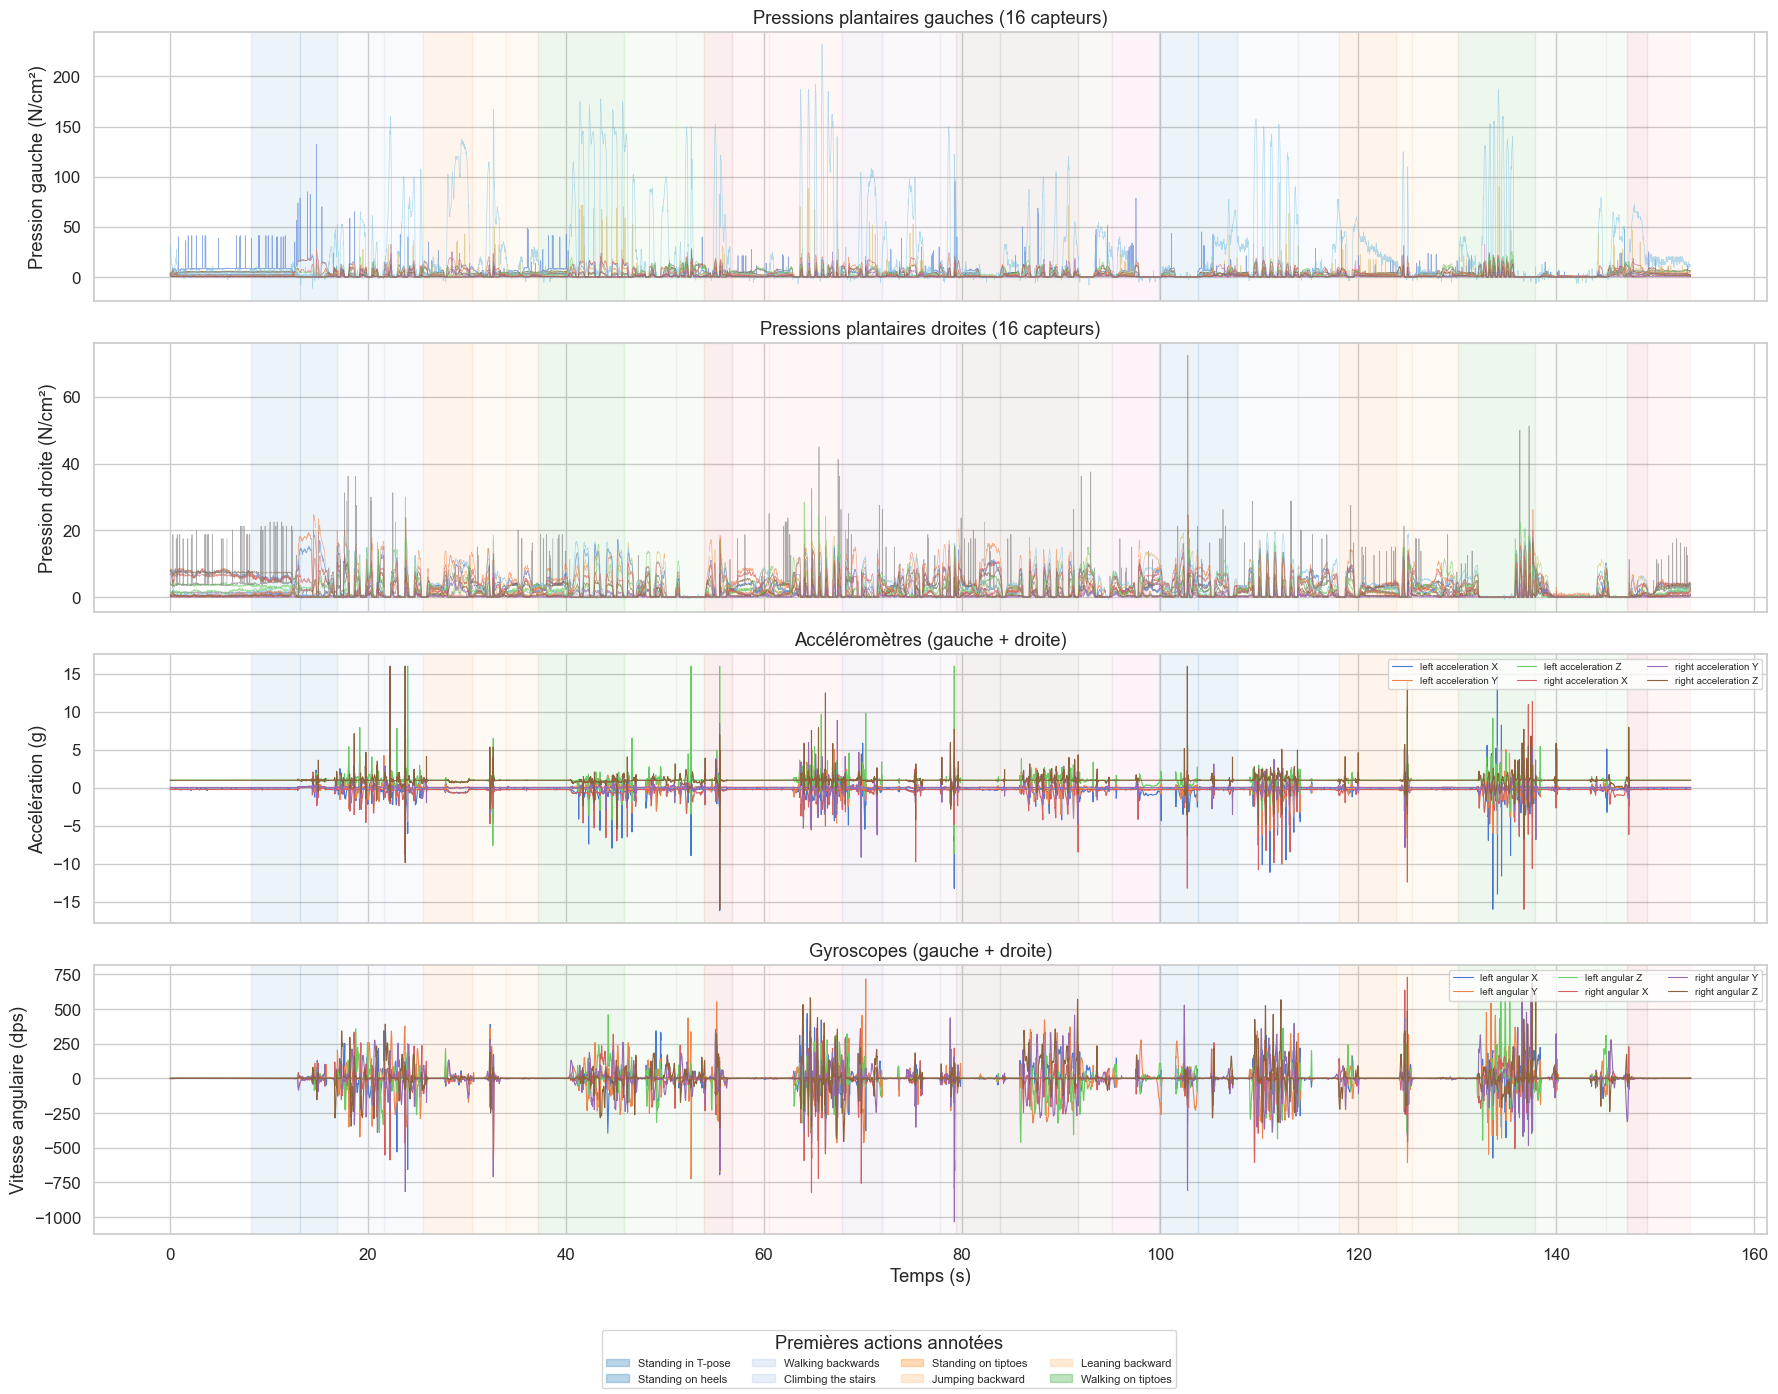

In [10]:
# --- Visualisation des signaux bruts avec annotations ---
_df_sig = pd.read_csv(plantar_root / "S01" / "Sequence_01" / "insoles.csv", sep=";")
_df_ann = pd.read_csv(events_root / "S01" / "Sequence_01" / "classif.csv", sep=";")
_time = _df_sig["Time"].values

# Colonnes par type de capteur
_pressure_cols_L = [c for c in _df_sig.columns if c.startswith("left pressure")]
_pressure_cols_R = [c for c in _df_sig.columns if c.startswith("right pressure")]
_accel_cols = [c for c in _df_sig.columns if "acceleration" in c]
_angular_cols = [c for c in _df_sig.columns if "angular" in c]
_force_cols = [c for c in _df_sig.columns if "total force" in c]

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)

# Plot 1: Left pressures
for col in _pressure_cols_L:
    axes[0].plot(_time, _df_sig[col], alpha=0.6, linewidth=0.5)
axes[0].set_ylabel("Pression gauche (N/cm²)")
axes[0].set_title("Pressions plantaires gauches (16 capteurs)")

# Plot 2: Right pressures
for col in _pressure_cols_R:
    axes[1].plot(_time, _df_sig[col], alpha=0.6, linewidth=0.5)
axes[1].set_ylabel("Pression droite (N/cm²)")
axes[1].set_title("Pressions plantaires droites (16 capteurs)")

# Plot 3: Accelerations
for col in _accel_cols:
    axes[2].plot(_time, _df_sig[col], label=col.split("[")[0].strip(), linewidth=0.8)
axes[2].set_ylabel("Accélération (g)")
axes[2].set_title("Accéléromètres (gauche + droite)")
axes[2].legend(fontsize=7, ncol=3, loc="upper right")

# Plot 4: Angular velocities
for col in _angular_cols:
    axes[3].plot(_time, _df_sig[col], label=col.split("[")[0].strip(), linewidth=0.8)
axes[3].set_ylabel("Vitesse angulaire (dps)")
axes[3].set_title("Gyroscopes (gauche + droite)")
axes[3].set_xlabel("Temps (s)")
axes[3].legend(fontsize=7, ncol=3, loc="upper right")

# Overlay annotation regions
cmap = plt.cm.get_cmap("tab20", len(_df_ann))
for ax in axes:
    for idx, row in _df_ann.iterrows():
        ax.axvspan(row["Timestamp Start"], row["Timestamp End"],
                   alpha=0.08, color=cmap(idx % 20))

# Add a legend for the first few actions
_handles = [mpatches.Patch(color=cmap(i % 20), alpha=0.3, label=row["Name"])
            for i, (_, row) in enumerate(_df_ann.head(8).iterrows())]
fig.legend(handles=_handles, loc="lower center", ncol=4, fontsize=8,
           title="Premières actions annotées")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### Analyse des valeurs manquantes

Les capteurs physiques peuvent parfois ne pas transmettre de mesure (perte de signal, déconnexion momentanée) — ce qui génère des `NaN` (Not a Number) dans les fichiers CSV.

Il faut identifier quelles colonnes sont touchées et dans quelle proportion, car :
- Trop de NaN sur un capteur peut rendre sa feature peu fiable
- Les modèles de deep learning ne peuvent pas gérer les NaN directement — il faut les *imputer* (remplir) avant l'entraînement

Le graphique ci-dessous agrège les NaN sur tous les participants d'entraînement et de validation (S01–S24).


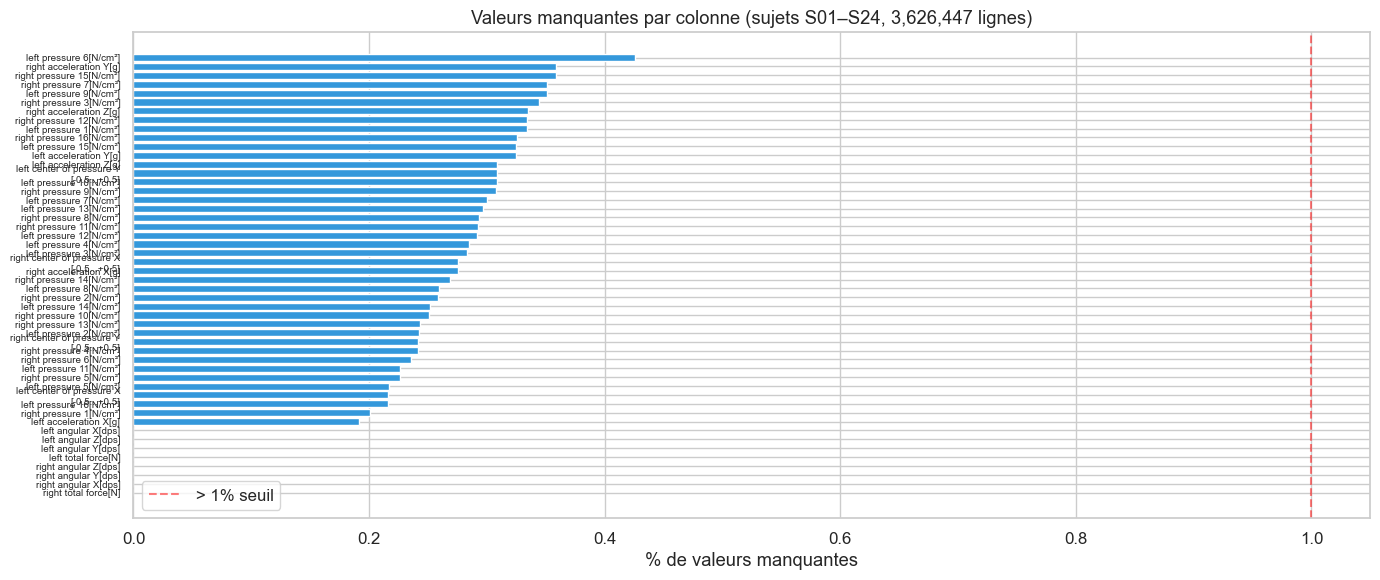

NaN max : 0.43% (left pressure 6[N/cm²])


In [11]:
# --- NaN % par colonne, agrégé sur tous les sujets d'entraînement ---
nan_counts = pd.Series(dtype=float)
total_rows = 0

for sid in range(1, 25):  # train+val subjects
    s_name = f"S{sid:02d}"
    for seq_dir in sorted((plantar_root / s_name).iterdir()):
        fpath = seq_dir / "insoles.csv"
        if not fpath.exists():
            continue
        df = pd.read_csv(fpath, sep=";")
        total_rows += len(df)
        nan_counts = nan_counts.add(df.isna().sum(), fill_value=0)

nan_pct = (nan_counts / total_rows * 100).drop("Time", errors="ignore").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#e74c3c" if v > 1 else "#3498db" for v in nan_pct.values]
ax.barh(range(len(nan_pct)), nan_pct.values, color=colors)
ax.set_yticks(range(len(nan_pct)))
ax.set_yticklabels([c.replace("[", "\n[") if len(c) > 30 else c for c in nan_pct.index], fontsize=7)
ax.set_xlabel("% de valeurs manquantes")
ax.set_title(f"Valeurs manquantes par colonne (sujets S01–S24, {total_rows:,} lignes)")
ax.invert_yaxis()
ax.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="> 1% seuil")
ax.legend()
plt.tight_layout()
plt.show()
print(f"NaN max : {nan_pct.max():.2f}% ({nan_pct.idxmax()})")

### Distributions des valeurs par type de capteur

Les différents capteurs mesurent des grandeurs physiques très différentes : des pressions en N/cm², des accélérations en g, des vitesses angulaires en degrés/seconde… Ces **échelles très hétérogènes** posent problème pour l'apprentissage : un réseau de neurones aura du mal à traiter conjointement des valeurs allant de 0 à 1 et des valeurs allant de -500 à 500.

Ces box plots permettent de visualiser la distribution de chaque groupe de capteurs et de **justifier le besoin d'une normalisation** avant d'entraîner le modèle.


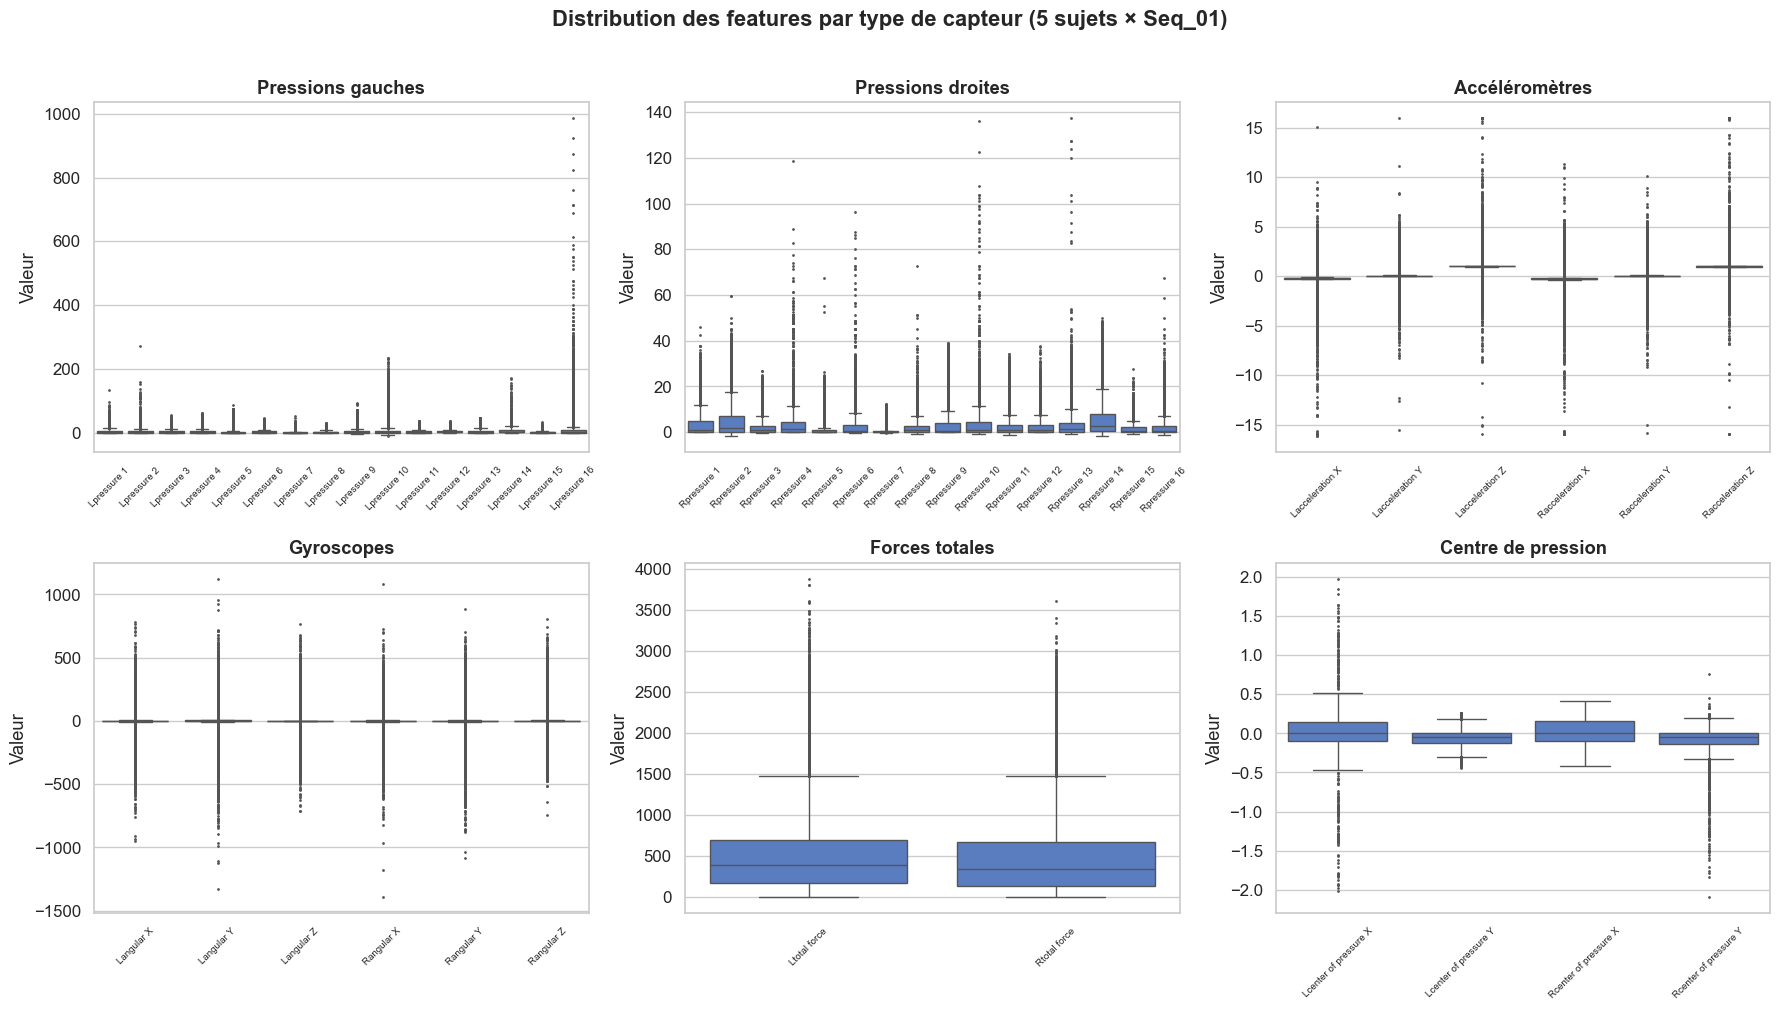

In [12]:
# --- Box plots par type de capteur (échantillon pour rapidité) ---
_sample_frames = []
for sid in [1, 5, 10, 15, 20]:
    fpath = plantar_root / f"S{sid:02d}" / "Sequence_01" / "insoles.csv"
    if fpath.exists():
        _sample_frames.append(pd.read_csv(fpath, sep=";"))
_df_all = pd.concat(_sample_frames, ignore_index=True).drop(columns=["Time"])
_df_all = _df_all.interpolate(method="linear", limit_direction="both").ffill().bfill().fillna(0)

# Group columns by sensor type
_groups = {
    "Pressions gauches": [c for c in _df_all.columns if c.startswith("left pressure")],
    "Pressions droites": [c for c in _df_all.columns if c.startswith("right pressure")],
    "Accéléromètres":    [c for c in _df_all.columns if "acceleration" in c],
    "Gyroscopes":        [c for c in _df_all.columns if "angular" in c],
    "Forces totales":    [c for c in _df_all.columns if "total force" in c],
    "Centre de pression":[c for c in _df_all.columns if "center of pressure" in c],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (name, cols) in enumerate(_groups.items()):
    if i >= len(axes):
        break
    _sub = _df_all[cols].melt(var_name="Capteur", value_name="Valeur")
    # Shorten labels
    _sub["Capteur"] = _sub["Capteur"].str.replace("left ", "L").str.replace("right ", "R")
    _sub["Capteur"] = _sub["Capteur"].str.split("[").str[0].str.strip()
    sns.boxplot(data=_sub, x="Capteur", y="Valeur", ax=axes[i], fliersize=1)
    axes[i].set_title(name, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)
    axes[i].set_xlabel("")
plt.suptitle("Distribution des features par type de capteur (5 sujets × Seq_01)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Distribution des classes : y a-t-il un déséquilibre ?

Dans un dataset de classification, un **déséquilibre de classes** (certaines actions beaucoup plus fréquentes que d'autres) est un problème courant. Si le modèle voit 10 fois plus d'exemples de "Marche" que de "Saut arrière", il a naturellement tendance à prédire "Marche" trop souvent.

Ce graphique compte le nombre total d'annotations par classe (participants S01–S24), pour mesurer ce déséquilibre et décider si on doit le compenser (par exemple en pondérant les classes lors de l'entraînement).


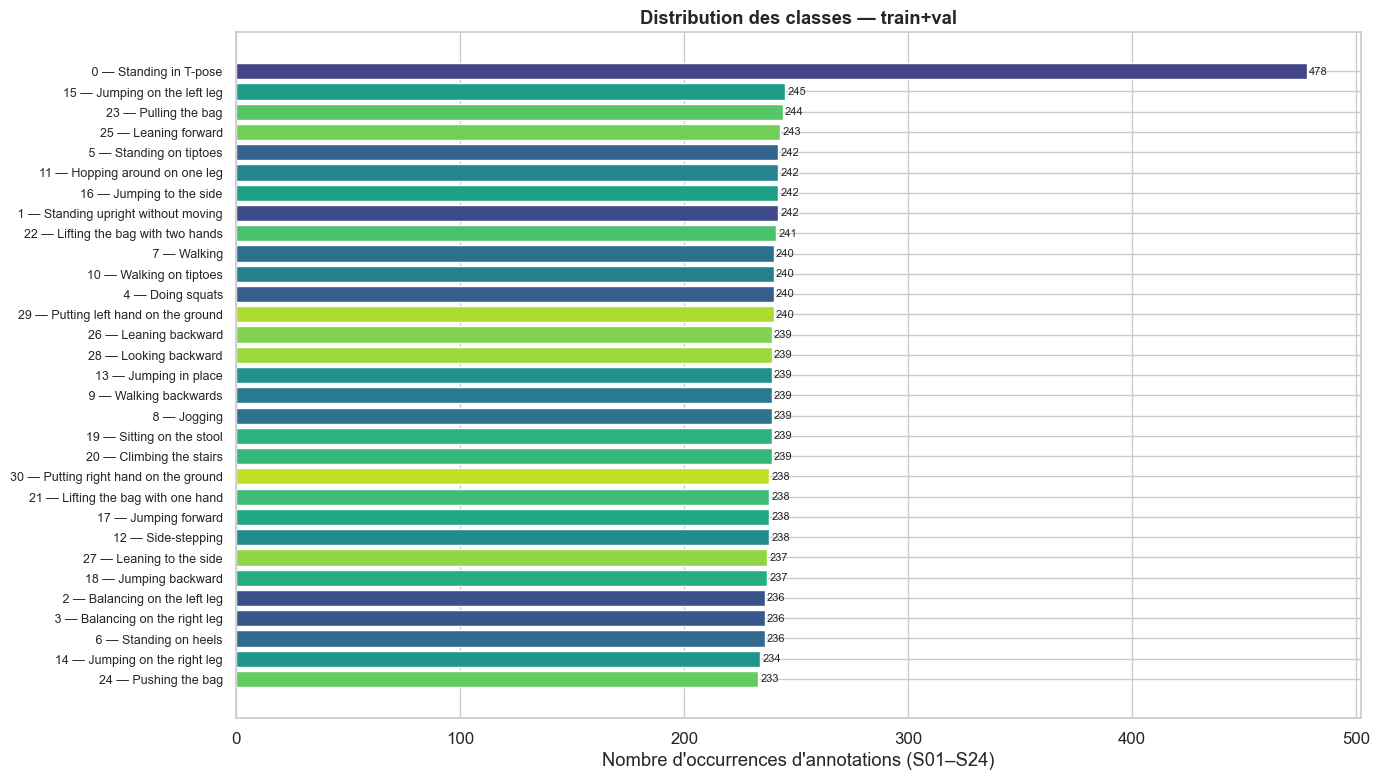

Ratio max/min : 2.1x — un déséquilibre modéré justifie l'utilisation de poids de classe.


In [13]:
# --- Distribution des classes (bar chart visuel) ---
_class_counts = Counter()
_class_durations = {i: [] for i in range(N_CLASSES)}

for sid in range(1, 25):
    s_name = f"S{sid:02d}"
    for ev_file in sorted((events_root / s_name).rglob("classif.csv")):
        ann = pd.read_csv(ev_file, sep=";")
        for _, row in ann.iterrows():
            cls = float(row["Class"])
            if cls in CLASS_MAP:
                lbl = CLASS_MAP[cls]
                _class_counts[lbl] += 1
                dur = float(row["Timestamp End"]) - float(row["Timestamp Start"])
                _class_durations[lbl].append(dur)

# Sort by count
_labels = list(range(N_CLASSES))
_counts_arr = np.array([_class_counts.get(i, 0) for i in _labels])
_sort_idx = np.argsort(_counts_arr)[::-1]

fig, ax = plt.subplots(figsize=(14, 8))
_colors_bar = plt.cm.viridis(np.linspace(0.2, 0.9, N_CLASSES))
bars = ax.barh(range(N_CLASSES), _counts_arr[_sort_idx], color=_colors_bar[_sort_idx])
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels([f"{_sort_idx[i]:2d} — {CLASS_NAMES[_sort_idx[i]]}" for i in range(N_CLASSES)], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Nombre d'occurrences d'annotations (S01–S24)")
ax.set_title("Distribution des classes — train+val", fontweight="bold")

# Annotate bars
for i, (cnt, bar) in enumerate(zip(_counts_arr[_sort_idx], bars)):
    ax.text(cnt + 1, i, str(cnt), va="center", fontsize=8)

plt.tight_layout()
plt.show()

_ratio = _counts_arr[_counts_arr > 0].max() / _counts_arr[_counts_arr > 0].min()
print(f"Ratio max/min : {_ratio:.1f}x — un déséquilibre modéré justifie l'utilisation de poids de classe.")

### Durée des annotations par classe

Toutes les actions ne durent pas le même temps. Si une action ne dure que 1 ou 2 secondes, et qu'on choisit de segmenter les données en fenêtres de 3 secondes, cette action risque d'être sous-représentée ou très bruitée.

Ce graphique montre la variabilité de durée pour chaque action, avec une ligne rouge indiquant la durée de fenêtre choisie (3s). Les actions dont la durée médiane est inférieure à cette ligne méritent une attention particulière.


C:\Users\QL6479\AppData\Local\Temp\ipykernel_23352\2941931074.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=_df_dur, y="Classe", x="Durée (s)", order=_order, ax=ax,


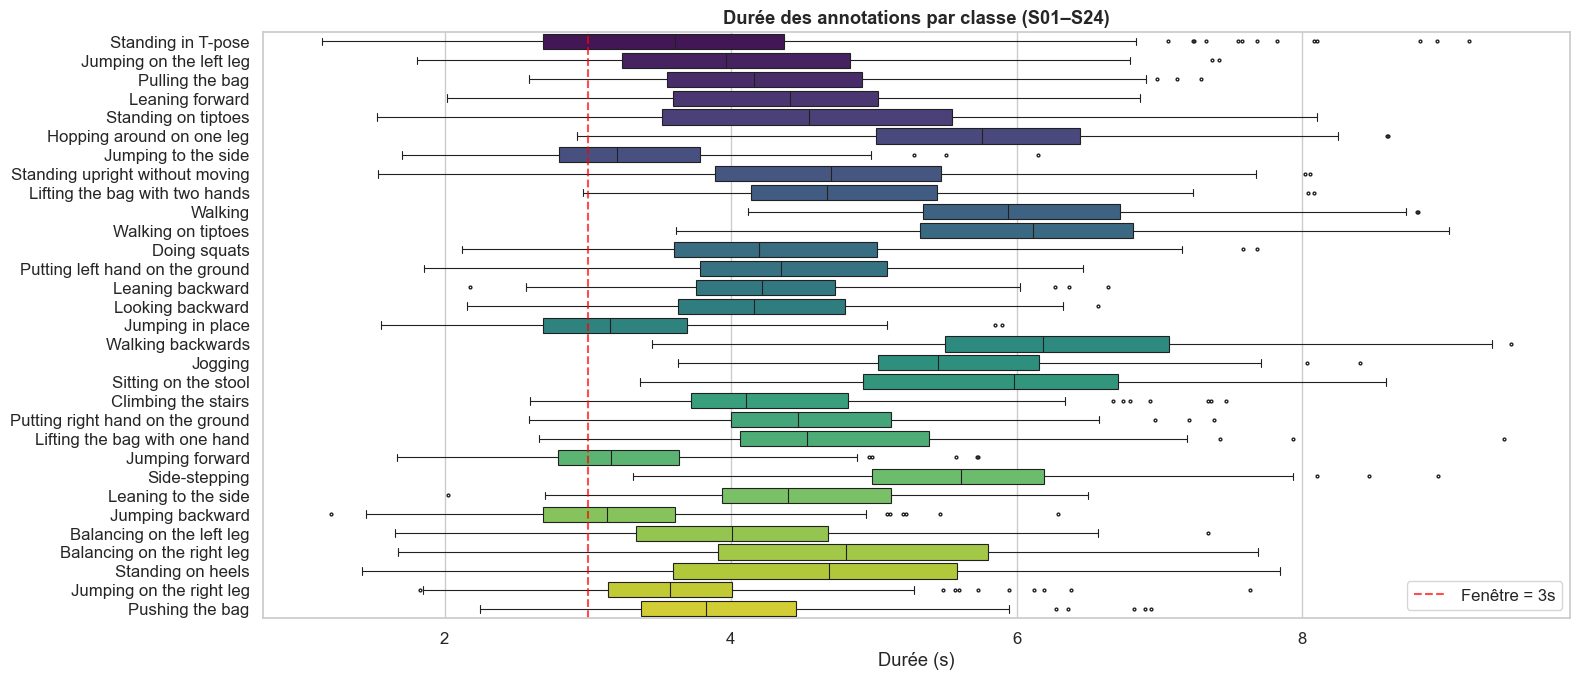

Actions courtes (< 3s) risquent d'être sous-représentées dans le fenêtrage.


In [14]:
# --- Durée des actions (box plot par classe) ---
_dur_data = []
for lbl, durs in _class_durations.items():
    for d in durs:
        _dur_data.append({"Classe": CLASS_NAMES[lbl], "Label": lbl, "Durée (s)": d})
_df_dur = pd.DataFrame(_dur_data)

fig, ax = plt.subplots(figsize=(16, 7))
_order = [CLASS_NAMES[i] for i in _sort_idx]
sns.boxplot(data=_df_dur, y="Classe", x="Durée (s)", order=_order, ax=ax,
            fliersize=2, linewidth=0.8, palette="viridis")
ax.set_title("Durée des annotations par classe (S01–S24)", fontweight="bold")
ax.set_ylabel("")
ax.axvline(x=3.0, color="red", linestyle="--", alpha=0.7, label="Fenêtre = 3s")
ax.legend()
plt.tight_layout()
plt.show()
print("Actions courtes (< 3s) risquent d'être sous-représentées dans le fenêtrage.")

### Matrice de corrélation entre les features

La matrice de corrélation montre à quel point deux capteurs mesurent la même chose. Si deux colonnes sont très corrélées (coefficient proche de 1 ou -1), l'une d'elles apporte peu d'information supplémentaire.

Cette analyse peut motiver une **réduction de dimensionnalité** (ex. PCA) ou simplement confirmer que les capteurs gauche/droit sont redondants pour certaines actions symétriques.


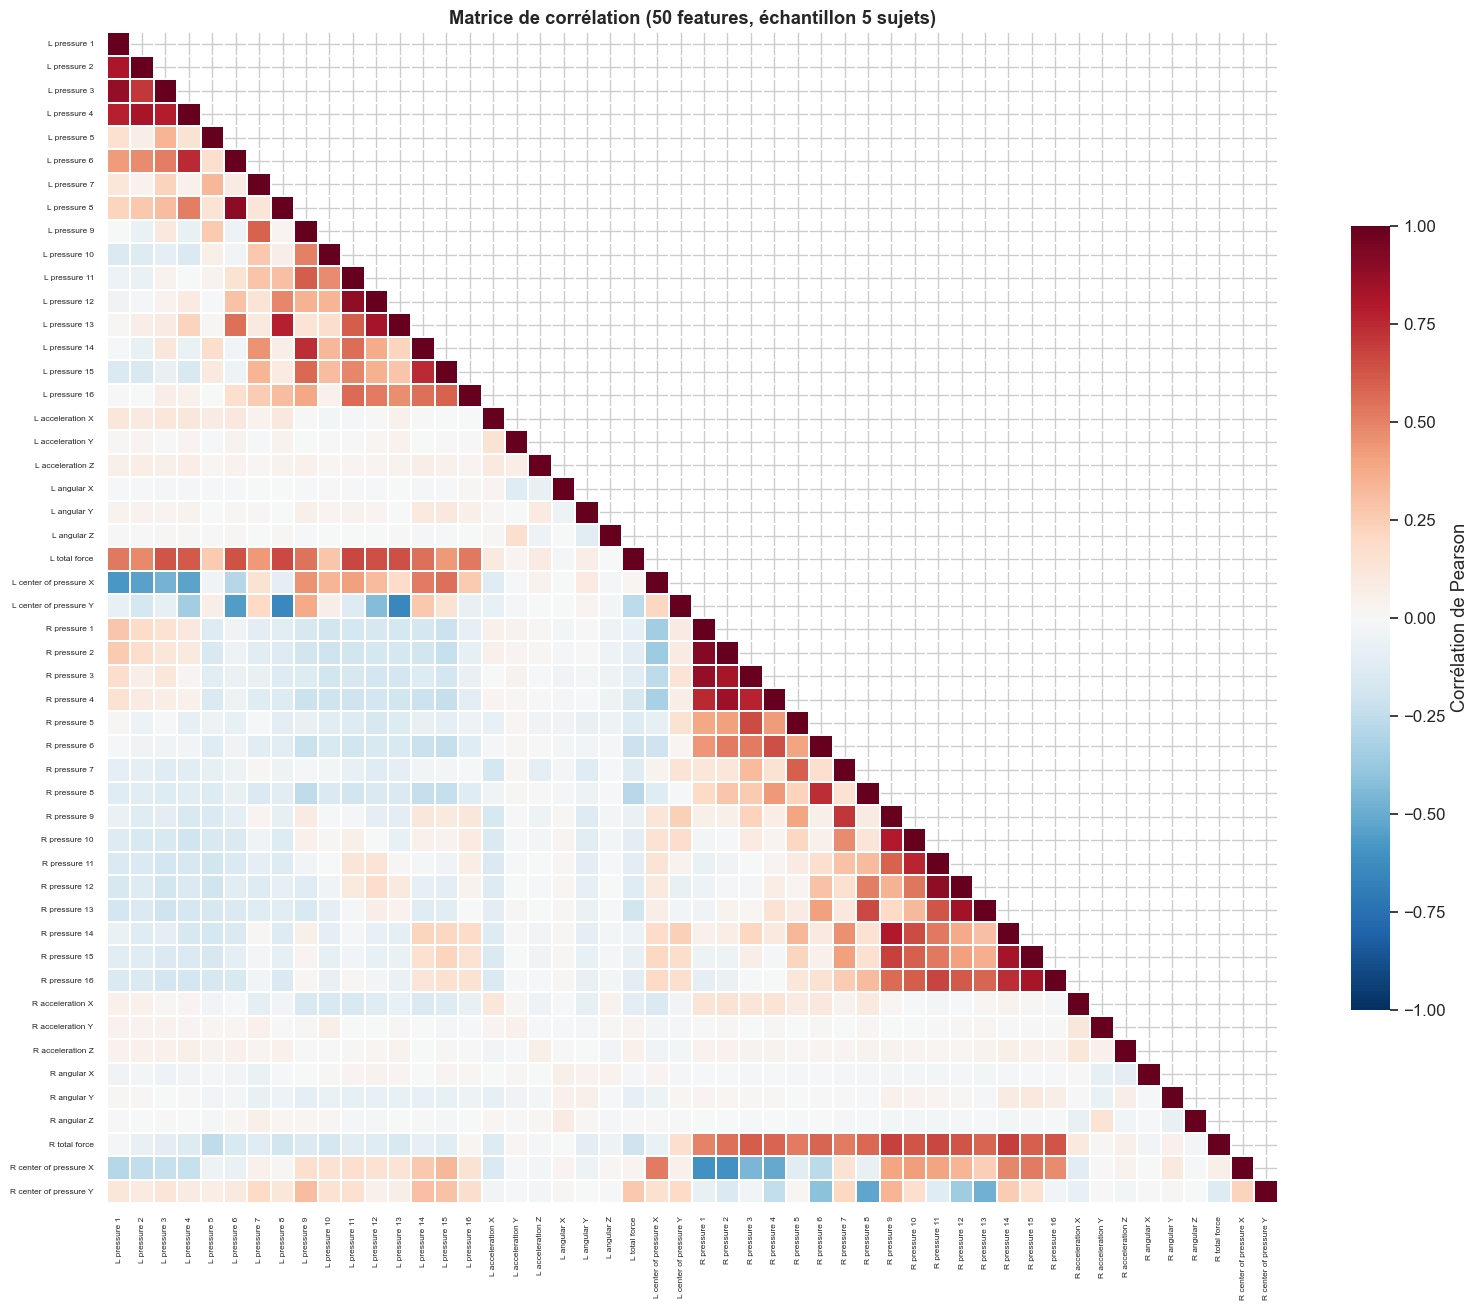

Les pressions gauche/droite sont fortement corrélées entre elles — possible réduction de dimension.


In [15]:
# --- Correlation heatmap (sample for speed) ---
_corr = _df_all.corr()

# Shorten column names
_short = {c: c.replace("left ", "L ").replace("right ", "R ").split("[")[0].strip() for c in _corr.columns}
_corr = _corr.rename(columns=_short, index=_short)

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(_corr, dtype=bool), k=1)
sns.heatmap(_corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Corrélation de Pearson"},
            xticklabels=True, yticklabels=True)
ax.set_title("Matrice de corrélation (50 features, échantillon 5 sujets)", fontweight="bold")
ax.tick_params(axis="both", labelsize=6)
plt.tight_layout()
plt.show()
print("Les pressions gauche/droite sont fortement corrélées entre elles — possible réduction de dimension.")

---
## 3. Prétraitement & Chargement

Les signaux bruts ne peuvent pas être donnés directement à un modèle. Il faut les transformer en exemples d'apprentissage structurés. Voici le pipeline complet :

**Étape 1 — Nettoyage des données**
Les valeurs manquantes (NaN) sont imputées par interpolation linéaire : on estime la valeur manquante à partir des valeurs avant et après. Si des NaN subsistent en début ou fin de séquence, on propage respectivement la première ou dernière valeur connue. En dernier recours, on remplace par 0.

**Étape 2 — Correction des annotations**
Certaines annotations indiquent une fin légèrement au-delà de la durée réelle du signal capteur (problème d'arrondi). On *clamp* (tronque) la fin de l'annotation à la dernière mesure disponible pour éviter les erreurs de découpage.

**Étape 3 — Fenêtrage glissant**
Plutôt que d'utiliser une séquence entière comme exemple, on la découpe en **fenêtres temporelles** de durée fixe. Ici, chaque fenêtre fait **3 secondes** = 300 échantillons à 100 Hz. Le *stride* (pas entre deux fenêtres) est de **1,5s à l'entraînement** (50% de chevauchement, ce qui multiplie les exemples) et de **3,0s en validation/test** (pas de chevauchement, évaluation non biaisée).

**Étape 4 — Attribution du label**
Chaque fenêtre est associée à la classe qui couvre le plus grand pourcentage de sa durée *(vote majoritaire)*. Si aucune classe ne couvre au moins 50% de la fenêtre, la fenêtre est rejetée.

**Étape 5 — Normalisation z-score**
Chaque feature est ramenée à une moyenne de 0 et un écart-type de 1. Cette normalisation est calculée **uniquement sur les données d'entraînement** et appliquée telle quelle à la validation et au test — pour éviter toute fuite d'information (*data leakage*).


### Chargement d'une séquence : `load_sequence()`

Cette fonction charge et nettoie une paire *(participant, séquence)* :
- Elle lit le fichier capteurs (`insoles.csv`) et impute les NaN
- Elle lit les annotations (`classif.csv`) et les *tronque* si elles dépassent la durée réelle du signal
- Elle ignore les annotations trop courtes (moins de 0,3 seconde après troncature) car elles ne fourniraient pas assez de signal pour apprendre

Elle retourne : le vecteur de temps, la matrice de features (shape `T × 50`) et la liste d'annotations nettoyées.


In [16]:
def load_sequence(subject_id: int, seq_name: str):
    """
    Load and clean one (subject, sequence) pair.
    Returns (times, features, annotations) or None if files are missing.
    - times:    np.ndarray[float64] shape (T,)
    - features: np.ndarray[float32] shape (T, 50)
    - annotations: list of (start_t, end_t, class_float)
    """
    s_name = f"S{subject_id:02d}"
    ev_path = events_root / s_name / seq_name / "classif.csv"
    pl_path = plantar_root / s_name / seq_name / "insoles.csv"
    if not ev_path.exists() or not pl_path.exists():
        return None

    # --- Insoles ---
    df = pd.read_csv(pl_path, sep=";")
    times = df["Time"].values.astype(np.float64)
    feats = df.drop(columns=["Time"])
    # NaN: linear interpolation → forward/backward fill → zero
    feats = feats.interpolate(method="linear", axis=0, limit_direction="both")
    feats = feats.ffill().bfill().fillna(0.0)
    features = feats.values.astype(np.float32)

    # --- Annotations ---
    ann = pd.read_csv(ev_path, sep=";")
    if len(ann) == 0:
        return None

    sensor_max_t = times[-1] if len(times) > 0 else 0.0
    annotations = []
    for _, row in ann.iterrows():
        t0 = float(row["Timestamp Start"])
        t1 = float(row["Timestamp End"])
        cls = float(row["Class"])

        # CRITICAL FIX: clamp annotation end to sensor time range
        t1_clamped = min(t1, sensor_max_t)
        if t1_clamped - t0 < 0.3:  # skip annotations shorter than 0.3s after clamping
            continue
        if cls not in CLASS_MAP:
            warnings.warn(f"Unknown class {cls} in {ev_path}")
            continue
        annotations.append((t0, t1_clamped, cls))

    return times, features, annotations

print("✓ load_sequence() définie")

✓ load_sequence() définie


### Découpage en fenêtres : `build_windows()`

**Analogie** : imaginez que vous lisez un long texte et que vous le découpez en paragraphes de 10 lignes, en avançant de 5 lignes à chaque fois (donc les paragraphes se chevauchent). C'est exactement ce que fait cette fonction avec le signal temporel.

Concrètement :
- **Fenêtre = 3 secondes** → 300 mesures consécutives
- La fenêtre avance de `stride_s` secondes à chaque pas
- Pour chaque fenêtre, on cherche quelle action recouvre le plus de temps (*vote majoritaire*)
- Si le recouvrement avec la meilleure action est **< 50 %**, la fenêtre est rejetée (trop ambiguë)
- Sinon, on enregistre : l'index de début, la longueur, et le label entier associé

À l'entraînement, le stride de 1,5s crée du **chevauchement intentionnel** : cela multiplie le nombre d'exemples et expose le modèle à des décalages temporels variés (forme d'augmentation de données).


In [17]:
def build_windows(times, features, annotations, duration_s, stride_s, fps=100):
    """
    Build sliding windows over the annotated region of one sequence.
    Returns list of (start_idx, window_len, label_int, overlap_frac).
    """
    window_len = int(round(duration_s * fps))
    results = []

    if not annotations:
        return results

    ann_start = annotations[0][0]
    ann_end   = annotations[-1][1]

    win_start_t = ann_start
    while win_start_t + duration_s <= ann_end + 0.01:
        win_end_t = win_start_t + duration_s

        # Majority-vote label
        best_label, best_overlap = None, 0.0
        for a0, a1, cls in annotations:
            overlap = max(0.0, min(win_end_t, a1) - max(win_start_t, a0))
            if overlap > best_overlap:
                best_overlap = overlap
                best_label = cls

        overlap_frac = best_overlap / duration_s
        if best_label is None or overlap_frac < 0.50:
            win_start_t += stride_s
            continue

        # Map to sensor indices
        start_idx = int(np.searchsorted(times, win_start_t))
        end_idx = start_idx + window_len
        if end_idx > len(times):
            break

        label_int = CLASS_MAP[best_label]
        results.append((start_idx, window_len, label_int, overlap_frac))
        win_start_t += stride_s

    return results

print("✓ build_windows() définie")

✓ build_windows() définie


### Vérification : les annotations sont-elles bien alignées avec les capteurs ?

Avant d'utiliser les données, on vérifie que toutes les annotations restent dans les limites temporelles du signal capteur. Si une annotation dépasse la durée du signal de plus de 0,1s, c'est un indicateur d'un problème de synchronisation — on le signale et on le corrige automatiquement par troncature.


In [18]:
def validate_all_sequences(subjects=None):
    """Check alignment between annotations and sensor data for all subjects."""
    if subjects is None:
        subjects = list(range(1, 33))

    mismatch_count = 0
    total_sequences = 0
    for sid in subjects:
        s_name = f"S{sid:02d}"
        ev_dir = events_root / s_name
        if not ev_dir.exists():
            continue
        for ev_file in sorted(ev_dir.rglob("classif.csv")):
            seq_name = ev_file.parent.name
            total_sequences += 1

            ann = pd.read_csv(ev_file, sep=";")
            pl_path = plantar_root / s_name / seq_name / "insoles.csv"
            if not pl_path.exists():
                print(f"  MISSING insoles: {s_name}/{seq_name}")
                continue
            df = pd.read_csv(pl_path, sep=";")
            sensor_end = df["Time"].iloc[-1]
            ann_end = float(ann["Timestamp End"].iloc[-1])

            if ann_end > sensor_end + 0.1:
                shortfall = ann_end - sensor_end
                mismatch_count += 1
                if shortfall > 5.0:
                    print(f"  {s_name}/{seq_name}: ann ends {ann_end:.1f}s, "
                          f"sensor ends {sensor_end:.1f}s (Δ={shortfall:.1f}s)")

    print(f"\nValidation: {total_sequences} sequences, "
          f"{mismatch_count} with annotation > sensor time (clamped at load)")
    return mismatch_count

print("=== Data validation ===")
validate_all_sequences()

=== Data validation ===

Validation: 319 sequences, 0 with annotation > sensor time (clamped at load)


0

### Classe `WindowedPlantarDataset`

Cette classe hérite de `Dataset` (la classe de base PyTorch) et encapsule tout le pipeline de préparation des données :

1. **Chargement** : itère sur tous les participants et séquences demandés, appelle `load_sequence()` pour chacun
2. **Fenêtrage** : appelle `build_windows()` pour produire la liste de toutes les fenêtres, avec leur label
3. **Normalisation** : si aucune statistique n'est fournie, calcule la moyenne et l'écart-type sur les données chargées. Sinon, utilise les statistiques fournies (cas val/test — on réutilise celles du train)
4. **Interface `__getitem__`** : quand le DataLoader demande un exemple, on extrait la fenêtre, on la normalise, et on retourne un tenseur PyTorch `(x, y)` où `x` est de forme `[300, 50]` et `y` est le label entier

Cette conception en classe évite de tout stocker en mémoire d'un coup et facilite la réutilisation (train/val/test avec les mêmes stats de normalisation).


In [19]:
class WindowedPlantarDataset(Dataset):
    """Sliding-window dataset for plantar action recognition."""

    def __init__(
        self,
        subjects,
        duration_s=3.0,
        stride_s=1.0,
        fps=100,
        transform=None,
        feat_mean=None,
        feat_std=None,
    ):
        self.transform = transform
        self.window_len = int(round(duration_s * fps))
        self.n_features = 0

        self._data = {}      # (sid, seq) → np.ndarray[float32] shape (T, F)
        self._times = {}     # (sid, seq) → np.ndarray[float64] shape (T,)
        self.samples = []    # (key, start_idx, window_len, label_int)
        self.overlaps = []   # overlap fraction per sample

        print("Loading dataset …")
        for sid in tqdm(subjects, desc="Subjects"):
            s_name = f"S{sid:02d}"
            ev_dir = events_root / s_name
            if not ev_dir.exists():
                continue

            for ev_file in sorted(ev_dir.rglob("classif.csv")):
                seq_name = ev_file.parent.name
                result = load_sequence(sid, seq_name)
                if result is None:
                    continue

                times, features, annotations = result
                key = (sid, seq_name)
                self._data[key] = features
                self._times[key] = times

                windows = build_windows(
                    times, features, annotations, duration_s, stride_s, fps
                )
                for start_idx, wlen, label_int, ofrac in windows:
                    self.samples.append((key, start_idx, wlen, label_int))
                    self.overlaps.append(ofrac)

        self.labels = np.array([lbl for _, _, _, lbl in self.samples], dtype=np.int64)

        if self._data:
            self.n_features = next(iter(self._data.values())).shape[1]

        # --- z-score normalization ---
        if feat_mean is not None and feat_std is not None:
            self.feat_mean = feat_mean
            self.feat_std = feat_std
        else:
            accum = np.zeros(self.n_features, dtype=np.float64)
            accum_sq = np.zeros(self.n_features, dtype=np.float64)
            n_rows = 0
            for key, start_idx, wlen, _ in self.samples:
                chunk = self._data[key][start_idx : start_idx + wlen]
                accum += chunk.sum(axis=0)
                accum_sq += (chunk.astype(np.float64) ** 2).sum(axis=0)
                n_rows += chunk.shape[0]

            if n_rows > 0:
                mean = (accum / n_rows).astype(np.float32)
                std = np.sqrt(accum_sq / n_rows - (accum / n_rows) ** 2).astype(np.float32)
                std[std < 1e-8] = 1.0
            else:
                mean = np.zeros(self.n_features, dtype=np.float32)
                std = np.ones(self.n_features, dtype=np.float32)

            self.feat_mean = mean
            self.feat_std = std

        n_classes_seen = len(set(self.labels))
        print(
            f"  → {len(self.samples)} samples, "
            f"{n_classes_seen}/{N_CLASSES} classes, "
            f"{self.n_features} features"
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        key, start_idx, wlen, _ = self.samples[idx]
        x = self._data[key][start_idx : start_idx + wlen].copy()
        x = (x - self.feat_mean) / self.feat_std
        x = torch.from_numpy(x)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            x = self.transform(x)
        return x, y

print("✓ WindowedPlantarDataset définie")

✓ WindowedPlantarDataset définie


### Création des datasets et des DataLoaders

On instancie trois datasets (train, val, test) avec les sujets correspondants. Remarquez que `val_ds` et `test_ds` reçoivent `feat_mean` et `feat_std` calculés sur le train — c'est essentiel pour éviter le *data leakage*.

Les **DataLoaders** encapsulent les datasets et gèrent le chargement par mini-lots (*batches*) :
- `batch_size=64` : le modèle voit 64 fenêtres à chaque pas de gradient
- `shuffle=True` pour l'entraînement : mélanger les exemples évite que le modèle apprenne l'ordre des séquences
- `pin_memory=True` : optimisation mémoire pour accélérer le transfert CPU→GPU


In [20]:
train_subjects = list(range(1, 21))   # S01-S20
val_subjects   = list(range(21, 25))  # S21-S24
test_subjects  = list(range(25, 33))  # S25-S32

DURATION = 3.0
STRIDE_TRAIN = 1.5             # 50% overlap for training (data augmentation)
STRIDE_EVAL  = DURATION        # NO overlap for val/test (unbiased evaluation)

train_ds = WindowedPlantarDataset(train_subjects, duration_s=DURATION, stride_s=STRIDE_TRAIN)
val_ds   = WindowedPlantarDataset(val_subjects,   duration_s=DURATION, stride_s=STRIDE_EVAL,
                                  feat_mean=train_ds.feat_mean, feat_std=train_ds.feat_std)
test_ds  = WindowedPlantarDataset(test_subjects,  duration_s=DURATION, stride_s=STRIDE_EVAL,
                                  feat_mean=train_ds.feat_mean, feat_std=train_ds.feat_std)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0,
                      pin_memory=True, generator=_g)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nRécapitulatif :")
print(f"  Train : {len(train_ds):5d} samples ({len(train_subjects)} sujets)")
print(f"  Val   : {len(val_ds):5d} samples ({len(val_subjects)} sujets)")
print(f"  Test  : {len(test_ds):5d} samples ({len(test_subjects)} sujets)")

Loading dataset …


Subjects:   0%|          | 0/20 [00:00<?, ?it/s]

  → 18978 samples, 31/31 classes, 50 features
Loading dataset …


Subjects:   0%|          | 0/4 [00:00<?, ?it/s]

  → 1899 samples, 31/31 classes, 50 features
Loading dataset …


Subjects:   0%|          | 0/8 [00:00<?, ?it/s]

  → 3817 samples, 31/31 classes, 50 features

Récapitulatif :
  Train : 18978 samples (20 sujets)
  Val   :  1899 samples (4 sujets)
  Test  :  3817 samples (8 sujets)


### Distribution des classes par split

Ce graphique vérifie que le déséquilibre de classes est cohérent entre les trois ensembles. Si une classe est absente dans la validation ou le test, les métriques associées ne seront pas fiables. Idéalement, toutes les classes doivent apparaître dans chaque split.


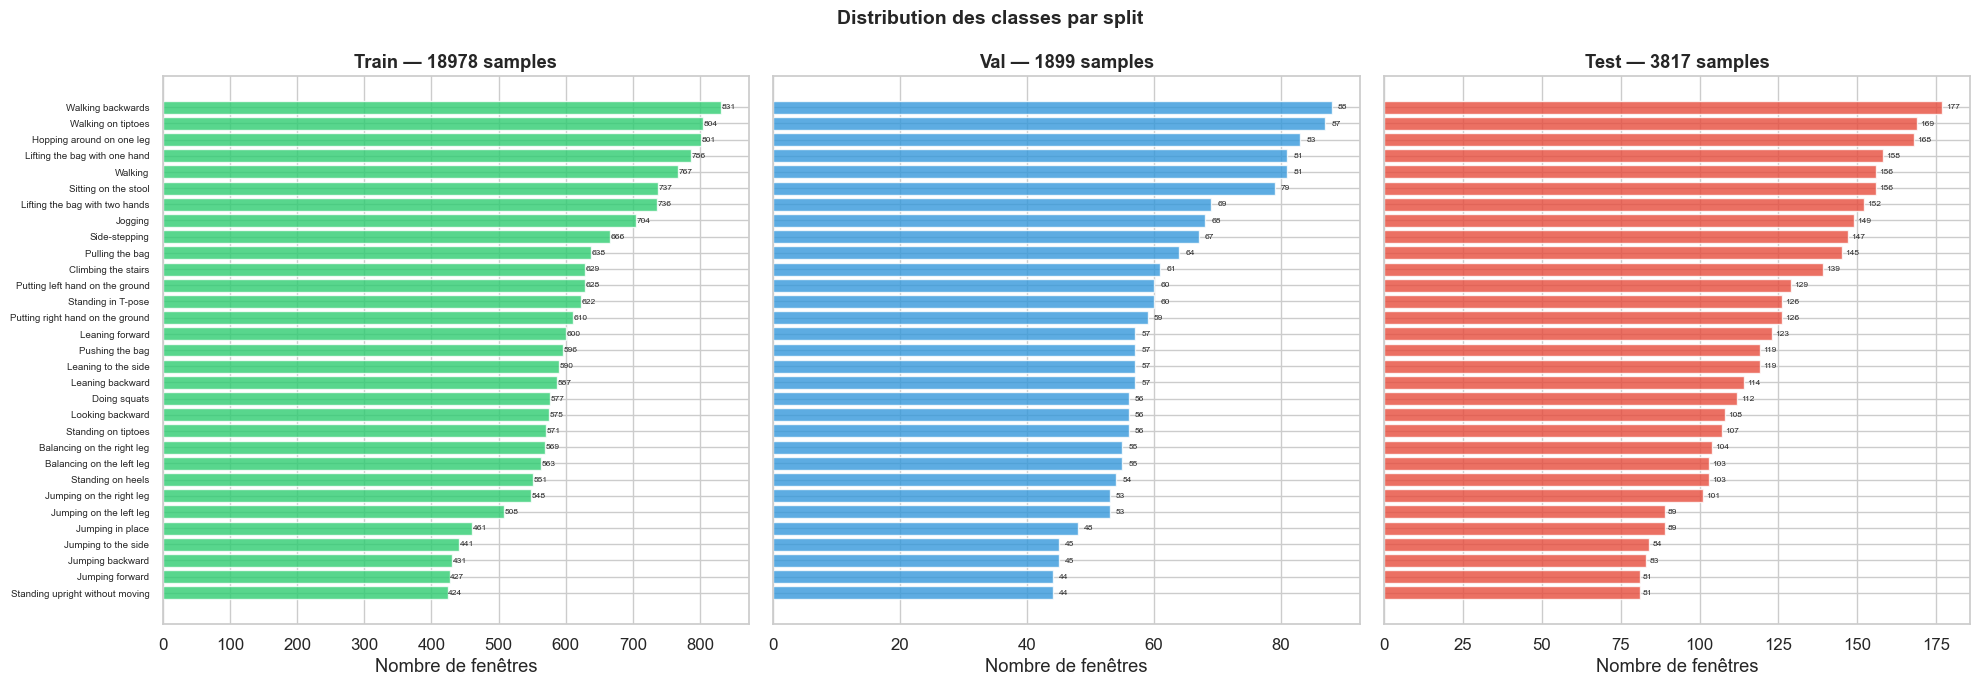

In [21]:
# --- Grouped bar chart: class distribution across splits ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for ax, (ds, name, color) in zip(axes, [
    (train_ds, "Train", "#2ecc71"),
    (val_ds, "Val", "#3498db"),
    (test_ds, "Test", "#e74c3c"),
]):
    counts = np.bincount(ds.labels, minlength=N_CLASSES)
    sort_idx = np.argsort(counts)[::-1]
    ax.barh(range(N_CLASSES), counts[sort_idx], color=color, alpha=0.8)
    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels([CLASS_NAMES[i] for i in sort_idx], fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("Nombre de fenêtres")
    ax.set_title(f"{name} — {counts.sum()} samples", fontweight="bold")

    # Annotate
    for i, cnt in enumerate(counts[sort_idx]):
        if cnt > 0:
            ax.text(cnt + 1, i, str(cnt), va="center", fontsize=6)

plt.suptitle("Distribution des classes par split", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

> **Note pour les étudiants** : les choix présentés ici (fenêtre de 3s, stride de 1,5s, seuil de recouvrement à 50%, normalisation z-score) sont des exemples de départ, pas des vérités absolues. Vous êtes attendus à **questionner, tester et justifier** vos propres choix en vous appuyant sur les observations faites lors de l'exploration.


---
## 4. Architecture du modèle

### CNN multi-échelle + BiGRU

L'architecture proposée combine deux types de réseaux complémentaires pour analyser les signaux temporels :

**1. CNN multi-échelle (extraction de motifs locaux)**

Une convolution 1D applique un filtre glissant sur le signal temporel pour détecter des *motifs locaux* (ex. un pic de pression caractéristique d'un impact au sol). Ici, on utilise trois filtres de tailles différentes (3, 5 et 7 points, soit 30ms, 50ms et 70ms) en parallèle. Cette **multi-échelle** permet de capturer des patterns à différentes résolutions temporelles. Les trois sorties sont concaténées puis fusionnées par deux convolutions supplémentaires.

**2. BiGRU (analyse des dépendances temporelles)**

Une fois les motifs locaux extraits par la CNN, le GRU (*Gated Recurrent Unit*) analyse la **dynamique temporelle** : comment les motifs s'enchaînent au fil du temps. Le préfixe "Bi" (*bidirectionnel*) signifie que le réseau lit le signal dans les deux sens (passé→futur et futur→passé), ce qui lui permet de mieux contextualiser chaque instant.

**3. Classification**

La sortie du GRU (une séquence de vecteurs) est moyennée sur la dimension temporelle (*Global Average Pooling*), puis passée dans deux couches entièrement connectées pour produire les 31 scores de classe.

```
Entrée [B, 300, 50]        ← batch de B fenêtres, 300 pas de temps, 50 features
    │
    ├── Conv1D (fenêtre 3 pts = 30ms) → 64 filtres ─┐
    ├── Conv1D (fenêtre 5 pts = 50ms) → 64 filtres ─┼── Concaténation → 192 canaux
    └── Conv1D (fenêtre 7 pts = 70ms) → 64 filtres ─┘
    │
    Conv1D → 128 canaux → BN → ReLU → Dropout
    Conv1D → 128 canaux → BN → ReLU → Dropout
    │
    BiGRU (2 couches, 128 neurones par direction) → 256 dimensions
    │
    Moyenne temporelle (GAP) → vecteur de 256 valeurs par fenêtre
    │
    FC(256→128) → ReLU → Dropout
    FC(128→31)  → 31 scores (un par classe)
```

**Couches de régularisation** :
- `BatchNorm` : normalise les activations pour stabiliser l'entraînement
- `Dropout` : désactive aléatoirement 30% des neurones à chaque passage pour éviter le surapprentissage


In [22]:
import torch.nn as nn

class ActionRecognitionNet(nn.Module):
    """Multi-scale 1D-CNN + BiGRU for plantar action recognition."""

    def __init__(self, n_features, n_classes, hidden_gru=128, dropout=0.3):
        super().__init__()

        # Multi-scale convolution branches (kernel 3, 5, 7)
        self.branch3 = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        # Fusion + deeper conv
        self.conv_merge = nn.Sequential(
            nn.Conv1d(64 * 3, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
        )
        # Bidirectional GRU
        self.gru = nn.GRU(128, hidden_gru, num_layers=2, batch_first=True,
                          bidirectional=True, dropout=dropout)
        # Classification head
        self.head = nn.Sequential(
            nn.Linear(hidden_gru * 2, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):              # x: [B, T, F]
        x = x.transpose(1, 2)         # -> [B, F, T]
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        x = torch.cat([b3, b5, b7], dim=1)  # [B, 192, T]
        x = self.conv_merge(x)               # [B, 128, T]
        x = x.transpose(1, 2)               # [B, T, 128]
        out, _ = self.gru(x)                 # [B, T, hidden*2]
        x = out.mean(dim=1)                  # [B, hidden*2]  (GAP)
        return self.head(x)

# --- Model summary ---
n_features = train_ds.n_features
n_classes  = N_CLASSES
_tmp_model = ActionRecognitionNet(n_features, n_classes, hidden_gru=128, dropout=0.3)
n_params = sum(p.numel() for p in _tmp_model.parameters() if p.requires_grad)
print(f"Architecture : {_tmp_model.__class__.__name__}")
print(f"Paramètres entraînables : {n_params:,}")
print(f"Entrée : [B, {300}, {n_features}] → Sortie : [B, {n_classes}]")
del _tmp_model

Architecture : ActionRecognitionNet
Paramètres entraînables : 703,711
Entrée : [B, 300, 50] → Sortie : [B, 31]


---
## 5. Entraînement

Un modèle s'entraîne en ajustant ses paramètres pour minimiser une **fonction de perte** (mesure de l'erreur entre la prédiction et la vérité). Le processus itère sur les mini-lots du dataset d'entraînement. Voici les choix faits ici :

| Choix | Valeur | Pourquoi |
|---|---|---|
| **Poids de classes** | Inversement proportionnels à la fréquence | Compense le déséquilibre : les classes rares contribuent autant à la perte que les classes fréquentes |
| **Optimiseur** | AdamW (lr=1e-3, weight_decay=1e-4) | Variante d'Adam avec régularisation L2, efficace sur la plupart des tâches de vision/signal |
| **Scheduler** | Cosine Annealing (T_max=50) | Réduit progressivement le taux d'apprentissage selon une courbe en cosinus, ce qui améliore la convergence |
| **Early stopping** | Patience de 8 epochs sur le F1 macro val. | Arrête l'entraînement si le modèle ne s'améliore plus, et conserve le meilleur état |
| **Gradient clipping** | max_norm=1.0 | Empêche les gradients de devenir trop grands (instabilité fréquente avec les GRU) |


### Fonctions d'entraînement et d'évaluation

`train_one_epoch()` réalise un passage complet sur le dataset d'entraînement : pour chaque mini-lot, on calcule la prédiction du modèle, la perte, les gradients, et on met à jour les paramètres.

`evaluate()` passe le modèle en mode évaluation (les couches Dropout et BatchNorm se comportent différemment) et calcule la perte, l'accuracy, le F1 macro et la matrice de confusion sans mettre à jour les paramètres (`@torch.no_grad()`).


In [23]:
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from tqdm.auto import trange

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    all_pred, all_true = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())
    all_pred = np.concatenate(all_pred)
    all_true = np.concatenate(all_true)
    acc = correct / total
    f1  = f1_score(all_true, all_pred, average='macro', zero_division=0)
    cm  = confusion_matrix(all_true, all_pred)
    return loss_sum / total, acc, f1, cm, all_true, all_pred

print("✓ train_one_epoch() et evaluate() définies")

✓ train_one_epoch() et evaluate() définies


### Configuration de l'entraînement

On instancie le modèle, la fonction de perte (CrossEntropyLoss avec poids de classes), l'optimiseur et le scheduler. Les poids de classes sont calculés ici : chaque classe reçoit un poids d'autant plus grand qu'elle est rare dans le dataset d'entraînement.


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Poids de classes inversement proportionnels à la fréquence
label_counts = Counter(train_ds.labels.tolist())
total_samples = len(train_ds.labels)
class_weights = torch.ones(n_classes, dtype=torch.float32)
for c, cnt in label_counts.items():
    class_weights[c] = total_samples / (n_classes * cnt)
class_weights = class_weights.to(device)

model     = ActionRecognitionNet(n_features, n_classes, hidden_gru=128, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

print(f"Modèle : {sum(p.numel() for p in model.parameters() if p.requires_grad):,} paramètres")
print(f"Poids de classe — min: {class_weights.min():.2f}, max: {class_weights.max():.2f}")

Device : cpu
Modèle : 703,711 paramètres
Poids de classe — min: 0.74, max: 1.44


### Boucle d'entraînement

À chaque epoch, on :
1. Entraîne le modèle sur toutes les fenêtres du train (`train_one_epoch`)
2. Évalue sur la validation (`evaluate`) — sans mettre à jour les paramètres
3. Fait avancer le scheduler (ajuste le taux d'apprentissage)
4. Sauvegarde le modèle si le F1 macro sur la validation s'améliore
5. Incrémente le compteur de patience sinon — si la patience est épuisée, on arrête

La métrique de suivi est le **F1 macro** (moyenne du F1 sur toutes les classes, avec poids égaux), plus robuste que l'accuracy en présence de déséquilibre.


In [25]:
NUM_EPOCHS   = 50
PATIENCE     = 8
save_path    = "best_model.pth"

train_curve, val_curve = [], []
best_val_f1  = 0.0
patience_cnt = 0

for epoch in trange(1, NUM_EPOCHS + 1, desc="Entraînement"):
    tr_loss, tr_acc = train_one_epoch(model, train_dl, criterion, optimizer, device)
    va_loss, va_acc, va_f1, _, _, _ = evaluate(model, val_dl, criterion, device)
    scheduler.step()

    train_curve.append((tr_loss, tr_acc))
    val_curve.append((va_loss, va_acc, va_f1))

    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d} | lr {lr_now:.1e} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} F1m {va_f1:.3f}")

    if va_f1 > best_val_f1:
        best_val_f1  = va_f1
        patience_cnt = 0
        torch.save(model.state_dict(), save_path)
        print(f"  ↑ Meilleur modèle sauvegardé (F1 macro = {va_f1:.4f})")
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stopping à l'epoch {epoch} (patience={PATIENCE})")
            break

print(f"\nMeilleur F1 macro (val) : {best_val_f1:.4f}")

Entraînement:   0%|          | 0/50 [00:00<?, ?it/s]

c:\P\DataChallenge\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | lr 1.0e-03 | train loss 2.3889 acc 0.323 | val loss 1.7976 acc 0.482 F1m 0.443
  ↑ Meilleur modèle sauvegardé (F1 macro = 0.4434)


c:\P\DataChallenge\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02 | lr 1.0e-03 | train loss 1.6786 acc 0.531 | val loss 1.5914 acc 0.544 F1m 0.522
  ↑ Meilleur modèle sauvegardé (F1 macro = 0.5215)


c:\P\DataChallenge\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

> **Note pour les étudiants** : le modèle, les hyperparamètres et la stratégie d'entraînement présentés ici sont un point de départ, pas une solution optimale. Vous êtes encouragés à **explorer d'autres architectures** (Transformer, ResNet 1D, TCN…), d'autres schedulers, d'autres techniques d'augmentation de données, et à **comparer vos résultats** de façon rigoureuse et argumentée.


---
## 6. Évaluation & Reporting

L'entraînement terminé, on charge le **meilleur modèle sauvegardé** (celui avec le meilleur F1 macro sur la validation) et on l'évalue sur le jeu de test — des participants que le modèle n'a *jamais* vus.

Cette section présente trois outils de diagnostic complémentaires :
1. **Courbes d'apprentissage** : suivre comment la performance évolue au fil des epochs pour détecter le surapprentissage
2. **Matrice de confusion** : voir quelles classes sont bien reconnues et lesquelles sont confondues entre elles
3. **Métriques par classe** : identifier les actions les plus difficiles à reconnaître


### Courbes d'apprentissage

Ces courbes montrent l'évolution de trois métriques au fil des epochs :

- **Loss** : la perte diminue-t-elle régulièrement ? Si la perte de validation remonte alors que la perte d'entraînement continue de descendre, cela signale du **surapprentissage** (overfitting) — le modèle mémorise les données d'entraînement au lieu d'apprendre des patterns généralisables.
- **Accuracy** : proportion de fenêtres correctement classifiées. Simple à interpréter mais sensible au déséquilibre.
- **F1 macro** : moyenne du F1-score sur toutes les classes. Plus robuste que l'accuracy quand les classes sont déséquilibrées — c'est la métrique pilote ici.


In [ ]:
epochs_range = range(1, len(train_curve) + 1)
tr_losses = [x[0] for x in train_curve]; tr_accs = [x[1] for x in train_curve]
va_losses = [x[0] for x in val_curve];   va_accs = [x[1] for x in val_curve]
va_f1s    = [x[2] for x in val_curve]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, tr_losses, label="train", linewidth=2)
axes[0].plot(epochs_range, va_losses, label="val", linewidth=2)
axes[0].set_title("Loss", fontweight="bold"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, tr_accs, label="train", linewidth=2)
axes[1].plot(epochs_range, va_accs, label="val", linewidth=2)
axes[1].set_title("Accuracy", fontweight="bold"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].set_ylim(0, 1); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, va_f1s, label="val F1 macro", color="green", linewidth=2)
axes[2].set_title("F1 Macro (validation)", fontweight="bold"); axes[2].set_xlabel("Epoch"); axes[2].legend()
axes[2].set_ylim(0, 1); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Évaluation sur le jeu de test

On charge le meilleur modèle (sauvegardé pendant l'entraînement) et on l'évalue sur les 8 participants de test. Le rapport de classification (`classification_report`) donne pour chaque classe : la précision (% des prédictions positives vraiment correctes), le rappel (% des exemples d'une classe effectivement retrouvés) et le F1-score (compromis entre les deux).


In [ ]:
# --- Load best model and evaluate on test set ---
best_model = ActionRecognitionNet(n_features, n_classes, hidden_gru=128, dropout=0.3).to(device)
best_model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
best_model.eval()

test_loss, test_acc, test_f1, cm, y_true, y_pred = evaluate(best_model, test_dl, criterion, device)
print(f"TEST | loss {test_loss:.4f} | acc {test_acc:.4f} | F1 macro {test_f1:.4f}")
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

### Matrice de confusion

La matrice de confusion est un tableau N×N (ici 31×31) où chaque ligne représente la **vraie classe** et chaque colonne la **classe prédite**. La diagonale contient les prédictions correctes.

- Les **cases hors-diagonale** révèlent les confusions systématiques : ex. si "Marche arrière" est souvent confondue avec "Marche", cela s'explique probablement par des signaux similaires.
- Les **lignes avec peu d'exemples** correspondent aux classes rares ou difficiles.

Lire cette matrice permet d'orienter les améliorations : faut-il plus de données pour certaines classes ? Des features plus discriminantes ?


In [ ]:
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Prédiction", fontsize=12)
plt.ylabel("Réel", fontsize=12)
plt.title(f"Matrice de Confusion — Test set (acc={test_acc:.3f}, F1m={test_f1:.3f})",
          fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

### Métriques par classe (Accuracy & F1)

Ces graphiques identifient visuellement les classes faciles (vert, F1 > 0,8), moyennes (orange) et difficiles (rouge, F1 < 0,5). C'est un point de départ pour l'analyse critique :
- Les classes difficiles sont-elles physiquement similaires à d'autres ? (ex. "Saut jambe gauche" vs "Saut jambe droite")
- Sont-elles sous-représentées dans le dataset ?
- Les signaux capteurs permettent-ils en théorie de les distinguer ?

Cette analyse doit nourrir vos propositions d'améliorations dans le rapport.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1_per, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(N_CLASSES), zero_division=0
)
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- Accuracy par classe ---
colors_acc = ["#e74c3c" if v < 0.5 else "#2ecc71" if v > 0.8 else "#f39c12" for v in per_class_acc]
axes[0].bar(range(N_CLASSES), per_class_acc, color=colors_acc, alpha=0.8)
axes[0].axhline(y=test_acc, color='navy', linestyle='--', linewidth=1.5,
                label=f'Moyenne globale ({test_acc:.3f})')
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy par classe — Test set", fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# --- F1 par classe ---
colors_f1 = ["#e74c3c" if v < 0.5 else "#2ecc71" if v > 0.8 else "#f39c12" for v in f1_per]
axes[1].bar(range(N_CLASSES), f1_per, color=colors_f1, alpha=0.8)
axes[1].axhline(y=test_f1, color='navy', linestyle='--', linewidth=1.5,
                label=f'F1 macro ({test_f1:.3f})')
axes[1].set_ylabel("F1 Score")
axes[1].set_title("F1 Score par classe — Test set", fontweight="bold")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\nClasses les plus difficiles (F1 < 0.5) :")
for i in range(N_CLASSES):
    if f1_per[i] < 0.5 and support[i] > 0:
        print(f"  {CLASS_NAMES[i]:>40s} — F1={f1_per[i]:.3f}, Acc={per_class_acc[i]:.3f}, Support={support[i]}")

---
## Ce qui est attendu de vous

Ce notebook est un **point de départ documenté**, pas une solution clé-en-main. Pour réussir le challenge, vous devez aller au-delà en proposant, testant et justifiant vos propres choix à chaque étape.

### Analyse exploratoire
- Statistiques descriptives par feature : min, max, moyenne, écart-type
- Détection d'outliers (valeurs aberrantes) et de valeurs manquantes
- Analyse approfondie du déséquilibre de classes et de ses conséquences
- Visualisations originales faisant ressortir des patterns

### Prétraitement
- Justifier le choix de la durée de fenêtre et du stride
- Justifier la stratégie de normalisation / standardisation
- Explorer d'autres stratégies d'imputation des NaN
- Tester des augmentations de données (bruit, décalage temporel, inversion gauche-droite…)

### Modélisation
- Proposer et comparer plusieurs architectures adaptées aux séries temporelles
- Justifier chaque hyperparamètre (profondeur, taille des couches, régularisation)
- Analyser les compromis biais/variance (sous/surapprentissage)

### Évaluation
- Utiliser plusieurs métriques : accuracy, F1 macro, F1 weighted, matrice de confusion
- Identifier et analyser les classes les plus difficiles à reconnaître
- Comparer vos résultats à d'autres configurations de façon rigoureuse

### Rapport et présentation
- Inclure des courbes d'apprentissage, des tableaux comparatifs de modèles, et une analyse critique
- Chaque décision doit être motivée par des observations et des résultats concrets
- Synthétiser les leçons apprises et les pistes d'amélioration non explorées
